In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "mrpc"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 3668
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1'], raw_train_dataset[5]['sentence2']

('Revenue in the first quarter of the year dropped 15 percent from the same period a year earlier .',
 "With the scandal hanging over Stewart 's company , revenue the first quarter of the year dropped 15 percent from the same period a year earlier .")

In [11]:
raw_train_dataset[5]['label']

1

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 100]),
 'token_type_ids': torch.Size([32, 100]),
 'attention_mask': torch.Size([32, 100])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(1.2996, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda', index=1)

### Load Trained Weights

In [26]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [27]:
from train_eval_func import eval_loop

In [28]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

### Load Trained Weights for Model with 7 Layers

In [29]:
import os
from merge_helper import merge_bert_layers, LayerMergeTracker, apply_layer_tracking_to_model
from train_eval_func import train, get_primary_metric, set_lr_scheduler, get_recovery_epoch
from torch.optim import AdamW

In [30]:
model_7 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-7-{task_name}.pt', map_location=device)

In [32]:
model_7 = apply_layer_tracking_to_model(model_7, graft_state['layer_track'])

In [33]:
len(model_7.bert.encoder.layer)

7

In [34]:
model_7.to(device)
device

device(type='cuda', index=1)

In [35]:
model_7.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [36]:
eval_loop(model_7, val_dataloader, task_name, device)[0]

{'accuracy': 0.8700980392156863, 'f1': 0.9084628670120898}

### Load Trained Weights for Model with 8 Layers

In [37]:
model_8 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [38]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-8-{task_name}.pt', map_location=device)

In [40]:
model_8 = apply_layer_tracking_to_model(model_8, graft_state['layer_track'])

In [41]:
len(model_8.bert.encoder.layer)

8

In [42]:
model_8.to(device)
device

device(type='cuda', index=1)

In [43]:
model_8.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [44]:
eval_loop(model_8, val_dataloader, task_name, device)[0]

{'accuracy': 0.8578431372549019, 'f1': 0.8996539792387543}

### Load Trained Weights for Model with 6 Layers

In [45]:
model_6 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [46]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-6-{task_name}.pt', map_location=device)

In [47]:
model_6 = apply_layer_tracking_to_model(model_6, graft_state['layer_track'])

In [48]:
len(model_6.bert.encoder.layer)

6

In [49]:
model_6.to(device)
device

device(type='cuda', index=1)

In [50]:
model_6.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [51]:
eval_loop(model_6, val_dataloader, task_name, device)[0]

{'accuracy': 0.8480392156862745, 'f1': 0.8938356164383562}

# 5. Pruning Study

In [52]:
analysis_save_path = f'./save_analysis/{task_name}'

### Masking 10 percent of amount

In [53]:
num_att_mask = int(12 * 12 * 0.1)
num_att_mask

14

In [54]:
num_int_mask = int(model.bert.encoder.layer[0].intermediate.dense.weight.shape[0] * 12 * 0.1)
num_int_mask

3686

## 5.1 Attention Heads

### 12 Layers

In [55]:
from structure_prune_helper import register_importance_masks, remove_importance_masks, iterativeMask, plot_results, plot_masking_comparison

In [56]:
register_importance_masks(model, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (12 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (12 heads)
  Layer 5: Registered masks (12 heads)
  Layer 6: Registered masks (12 heads)
  Layer 7: Registered masks (12 heads)
  Layer 8: Registered masks (12 heads)
  Layer 9: Registered masks (12 heads)
  Layer 10: Registered masks (12 heads)
  Layer 11: Registered masks (12 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [57]:
mask_history_head = iterativeMask(
    model, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
      accuracy: 0.8676
    ★ f1: 0.9094

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:44<00:00,  2.22it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 12, Remain: 12 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 12, Remain: 12 (100.0%)
Layer: 6, total: 12, Remain: 12 (100.0%)
Layer: 7, total: 12, Remain: 10 (83.33%)
Layer: 8, total: 12, Remain: 12 (100.0%)
Layer: 9, total: 12, Remain: 11 (91.67%)
Layer: 10, total: 12, Remain: 7 (58.33%)
Layer: 11, total: 12, Remain: 6 (50.0%)
  Metrics:
      accuracy: 0.8676
    ★ f1: 0.9094

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:40<00:00,  2.49it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 12, Remain: 12 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 12, Remain: 12 (100.0%)
Layer: 6, total: 12, Remain: 11 (91.67%)
Layer: 7, total: 12, Remain: 9 (75.0%)
Layer: 8, total: 12, Remain: 8 (66.67%)
Layer: 9, total: 12, Remain: 7 (58.33%)
Layer: 10, total: 12, Remain: 5 (41.67%)
Layer: 11, total: 12, Remain: 4 (33.33%)
  Metrics:
      accuracy: 0.8652
    ★ f1: 0.9079

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 2 (16.67%)
Layer: 1, total: 12, Remain: 7 (58.33%)
Layer: 2, total: 12, Remain: 7 (58.33%)
Layer: 3, total: 12, Remain: 7 (58.33%)
Layer: 4, total: 12, Remain: 6 (50.0%)
Layer: 5, total: 12, Remain: 4 (33.33%)
Layer: 6, total: 12, Remain: 3 (25.0%)
Layer: 7, total: 12, Remain: 2 (16.67%)
Layer: 8, total: 12, Remain: 5 (41.67%)
Layer: 9, total: 12, Remain: 2 (16.67%)
Layer: 10, total: 12, Remain: 0 (0.0%)
Layer: 11, total: 12, Remain: 1 (8.33%)
  Metrics:
      accuracy: 0.8382
    ★ f1: 0.8885

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:28<00:00,  3.47it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 2 (16.67%)
Layer: 1, total: 12, Remain: 6 (50.0%)
Layer: 2, total: 12, Remain: 3 (25.0%)
Layer: 3, total: 12, Remain: 5 (41.67%)
Layer: 4, total: 12, Remain: 5 (41.67%)
Layer: 5, total: 12, Remain: 3 (25.0%)
Layer: 6, total: 12, Remain: 3 (25.0%)
Layer: 7, total: 12, Remain: 0 (0.0%)
Layer: 8, total: 12, Remain: 2 (16.67%)
Layer: 9, total: 12, Remain: 2 (16.67%)
Layer: 10, total: 12, Remain: 0 (0.0%)
Layer: 11, total: 12, Remain: 1 (8.33%)
  Metrics:
      accuracy: 0.7672
    ★ f1: 0.8263

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:31<00:00,  3.20it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 1 (8.33%)
Layer: 1, total: 12, Remain: 3 (25.0%)
Layer: 2, total: 12, Remain: 2 (16.67%)
Layer: 3, total: 12, Remain: 3 (25.0%)
Layer: 4, total: 12, Remain: 3 (25.0%)
Layer: 5, total: 12, Remain: 2 (16.67%)
Layer: 6, total: 12, Remain: 1 (8.33%)
Layer: 7, total: 12, Remain: 0 (0.0%)
Layer: 8, total: 12, Remain: 1 (8.33%)
Layer: 9, total: 12, Remain: 1 (8.33%)
Layer: 10, total: 12, Remain: 0 (0.0%)
Layer: 11, total: 12, Remain: 1 (8.33%)
  Metrics:
      accuracy: 0.6912
    ★ f1: 0.7632


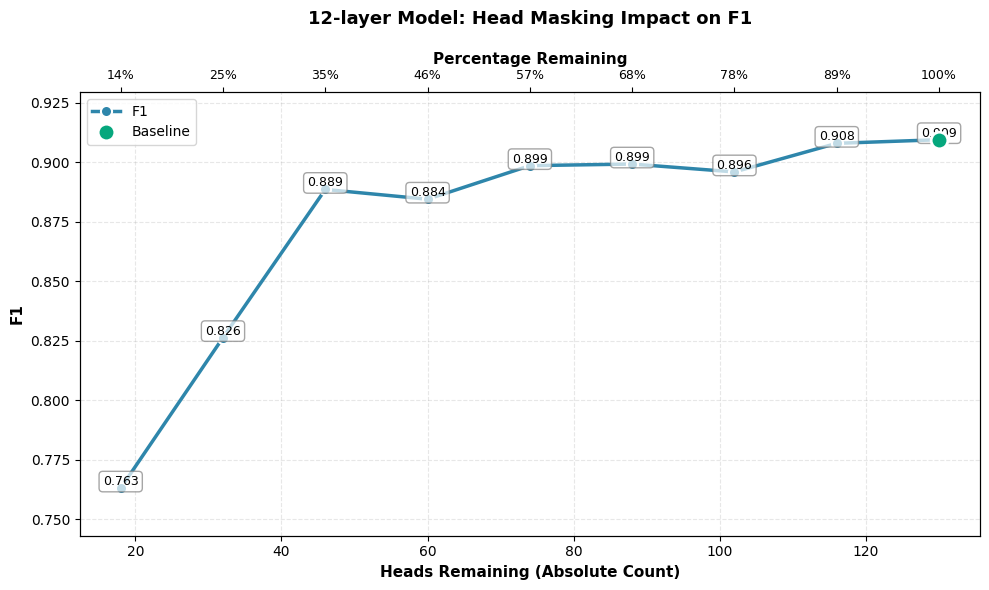

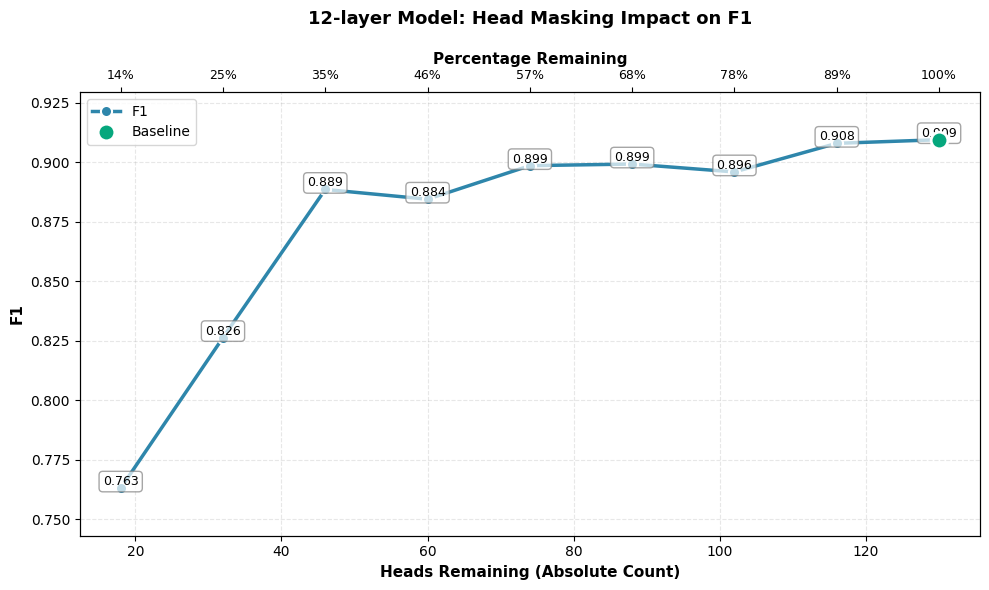

In [58]:
plot_results(
        mask_history_head,
        metric='f1',
        component='heads',
        title='12-layer Model: Head Masking Impact on F1'
)

In [59]:
remove_importance_masks(model, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [60]:
torch.save(mask_history_head, analysis_save_path + '/head.pt')

### 8 Layers

In [63]:
register_importance_masks(model_8, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (24 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (12 heads)
  Layer 5: Registered masks (24 heads)
  Layer 6: Registered masks (12 heads)
  Layer 7: Registered masks (36 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [64]:
mask_history_head_8 = iterativeMask(
    model_8, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
      accuracy: 0.8578
    ★ f1: 0.8997

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:28<00:00,  3.47it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 24, Remain: 20 (83.33%)
Layer: 6, total: 12, Remain: 12 (100.0%)
Layer: 7, total: 36, Remain: 26 (72.22%)
  Metrics:
      accuracy: 0.8529
    ★ f1: 0.8969

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:27<00:00,  3.62it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 11 (91.67%)
Layer: 5, total: 24, Remain: 19 (79.17%)
Layer: 6, total: 12, Remain: 9 (75.0%)
Layer: 7, total: 36, Remain: 17 (47.22%)
  Metrics:
      accuracy: 0.8554
    ★ f1: 0.8991

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 6 (50.0%)
Layer: 1, total: 24, Remain: 9 (37.5%)
Layer: 2, total: 12, Remain: 9 (75.0%)
Layer: 3, total: 12, Remain: 5 (41.67%)
Layer: 4, total: 12, Remain: 4 (33.33%)
Layer: 5, total: 24, Remain: 5 (20.83%)
Layer: 6, total: 12, Remain: 5 (41.67%)
Layer: 7, total: 36, Remain: 3 (8.33%)
  Metrics:
      accuracy: 0.8015
    ★ f1: 0.8606

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:31<00:00,  3.17it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 3 (25.0%)
Layer: 1, total: 24, Remain: 8 (33.33%)
Layer: 2, total: 12, Remain: 6 (50.0%)
Layer: 3, total: 12, Remain: 5 (41.67%)
Layer: 4, total: 12, Remain: 3 (25.0%)
Layer: 5, total: 24, Remain: 3 (12.5%)
Layer: 6, total: 12, Remain: 2 (16.67%)
Layer: 7, total: 36, Remain: 2 (5.56%)
  Metrics:
      accuracy: 0.7451
    ★ f1: 0.8201

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:25<00:00,  3.94it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 2 (16.67%)
Layer: 1, total: 24, Remain: 4 (16.67%)
Layer: 2, total: 12, Remain: 4 (33.33%)
Layer: 3, total: 12, Remain: 2 (16.67%)
Layer: 4, total: 12, Remain: 1 (8.33%)
Layer: 5, total: 24, Remain: 1 (4.17%)
Layer: 6, total: 12, Remain: 2 (16.67%)
Layer: 7, total: 36, Remain: 2 (5.56%)
  Metrics:
      accuracy: 0.3897
    ★ f1: 0.2145


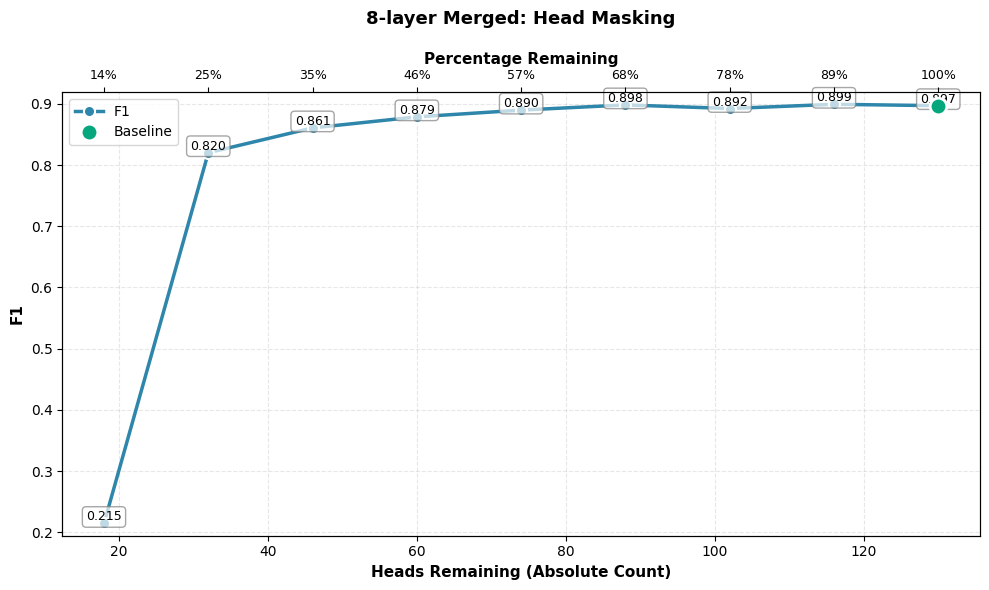

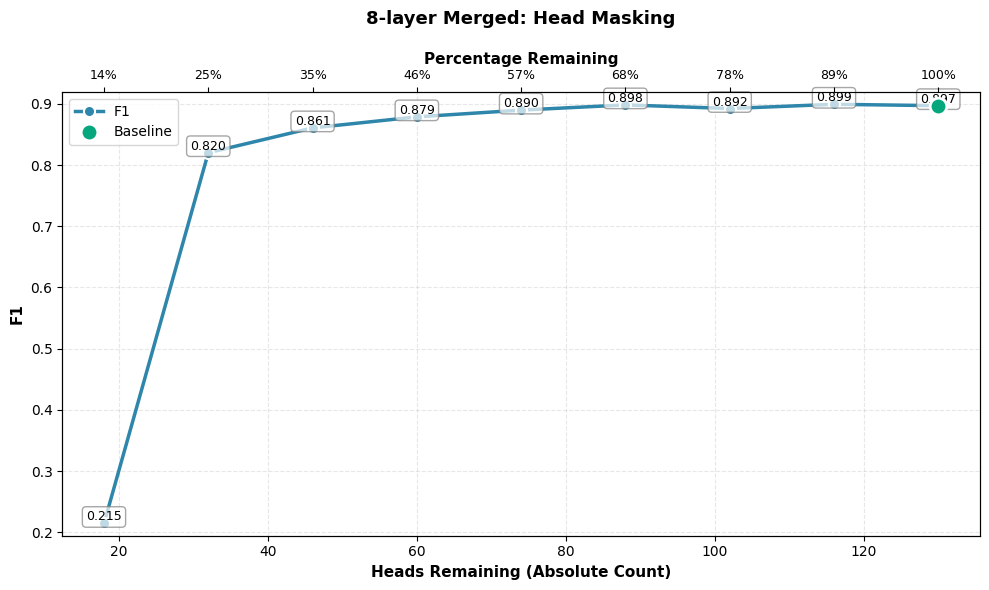

In [65]:
plot_results(
        mask_history_head_8,
        metric='f1',
        component='heads',
        title='8-layer Merged: Head Masking'
)

In [66]:
remove_importance_masks(model_8, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [67]:
torch.save(mask_history_head_8, analysis_save_path + '/head_8.pt')

### 7 Layers

In [68]:
register_importance_masks(model_7, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (24 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (12 heads)
  Layer 5: Registered masks (24 heads)
  Layer 6: Registered masks (48 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [69]:
mask_history_head_7 = iterativeMask(
    model_7, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
      accuracy: 0.8701
    ★ f1: 0.9085

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:37<00:00,  2.67it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 24, Remain: 23 (95.83%)
Layer: 6, total: 48, Remain: 35 (72.92%)
  Metrics:
      accuracy: 0.8578
    ★ f1: 0.9007

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:27<00:00,  3.61it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 24, Remain: 20 (83.33%)
Layer: 6, total: 48, Remain: 24 (50.0%)
  Metrics:
      accuracy: 0.8603
    ★ f1: 0.9026

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 7 (58.33%)
Layer: 1, total: 24, Remain: 11 (45.83%)
Layer: 2, total: 12, Remain: 7 (58.33%)
Layer: 3, total: 12, Remain: 5 (41.67%)
Layer: 4, total: 12, Remain: 5 (41.67%)
Layer: 5, total: 24, Remain: 5 (20.83%)
Layer: 6, total: 48, Remain: 6 (12.5%)
  Metrics:
      accuracy: 0.7672
    ★ f1: 0.8263

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:26<00:00,  3.82it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 4 (33.33%)
Layer: 1, total: 24, Remain: 7 (29.17%)
Layer: 2, total: 12, Remain: 5 (41.67%)
Layer: 3, total: 12, Remain: 5 (41.67%)
Layer: 4, total: 12, Remain: 3 (25.0%)
Layer: 5, total: 24, Remain: 3 (12.5%)
Layer: 6, total: 48, Remain: 5 (10.42%)
  Metrics:
      accuracy: 0.7377
    ★ f1: 0.8152

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:28<00:00,  3.54it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 1 (8.33%)
Layer: 1, total: 24, Remain: 4 (16.67%)
Layer: 2, total: 12, Remain: 4 (33.33%)
Layer: 3, total: 12, Remain: 4 (33.33%)
Layer: 4, total: 12, Remain: 1 (8.33%)
Layer: 5, total: 24, Remain: 2 (8.33%)
Layer: 6, total: 48, Remain: 2 (4.17%)
  Metrics:
      accuracy: 0.4804
    ★ f1: 0.4239


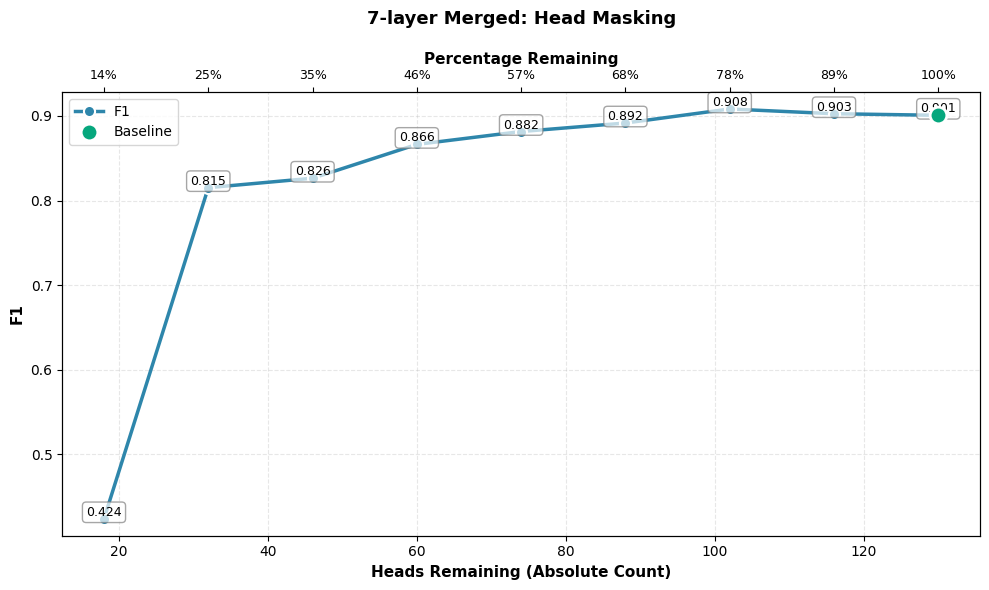

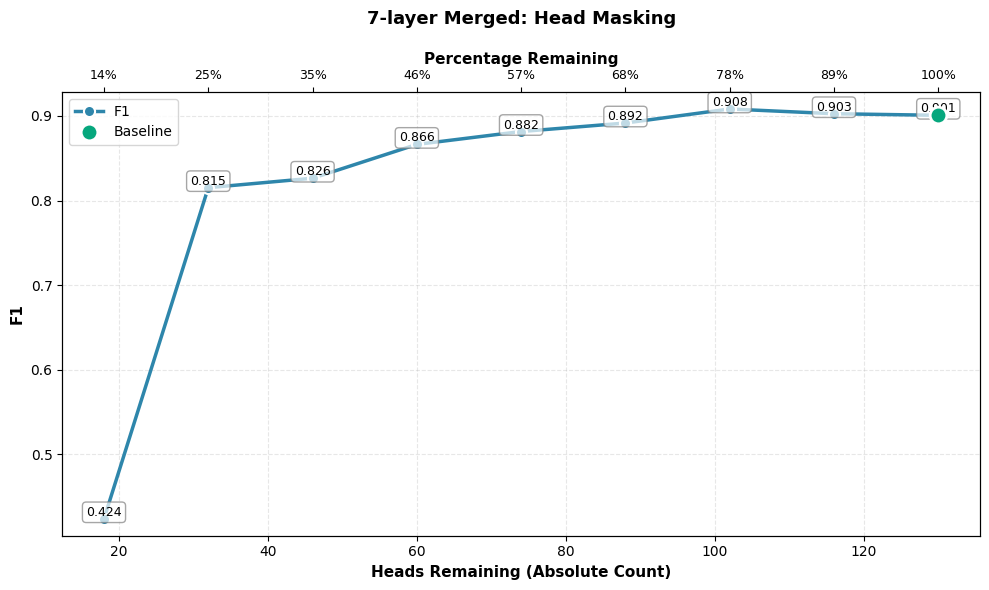

In [70]:
plot_results(
        mask_history_head_7,
        metric='f1',
        component='heads',
        title='7-layer Merged: Head Masking'
)

In [71]:
remove_importance_masks(model_7, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [72]:
torch.save(mask_history_head_7, analysis_save_path + '/head_7.pt')

### 6 Layers

In [73]:
register_importance_masks(model_6, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (24 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (36 heads)
  Layer 5: Registered masks (48 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [74]:
mask_history_head_6 = iterativeMask(
    model_6, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
      accuracy: 0.8480
    ★ f1: 0.8938

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:28<00:00,  3.56it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 36, Remain: 34 (94.44%)
Layer: 5, total: 48, Remain: 36 (75.0%)
  Metrics:
      accuracy: 0.8480
    ★ f1: 0.8946

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:26<00:00,  3.72it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 36, Remain: 30 (83.33%)
Layer: 5, total: 48, Remain: 26 (54.17%)
  Metrics:
      accuracy: 0.8431
    ★ f1: 0.8933

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 7 (58.33%)
Layer: 1, total: 24, Remain: 9 (37.5%)
Layer: 2, total: 12, Remain: 8 (66.67%)
Layer: 3, total: 12, Remain: 6 (50.0%)
Layer: 4, total: 36, Remain: 9 (25.0%)
Layer: 5, total: 48, Remain: 7 (14.58%)
  Metrics:
      accuracy: 0.8015
    ★ f1: 0.8620

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:27<00:00,  3.58it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 4 (33.33%)
Layer: 1, total: 24, Remain: 5 (20.83%)
Layer: 2, total: 12, Remain: 6 (50.0%)
Layer: 3, total: 12, Remain: 6 (50.0%)
Layer: 4, total: 36, Remain: 5 (13.89%)
Layer: 5, total: 48, Remain: 6 (12.5%)
  Metrics:
      accuracy: 0.7647
    ★ f1: 0.8384

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:27<00:00,  3.58it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 1 (8.33%)
Layer: 1, total: 24, Remain: 1 (4.17%)
Layer: 2, total: 12, Remain: 3 (25.0%)
Layer: 3, total: 12, Remain: 5 (41.67%)
Layer: 4, total: 36, Remain: 4 (11.11%)
Layer: 5, total: 48, Remain: 4 (8.33%)
  Metrics:
      accuracy: 0.6985
    ★ f1: 0.8145


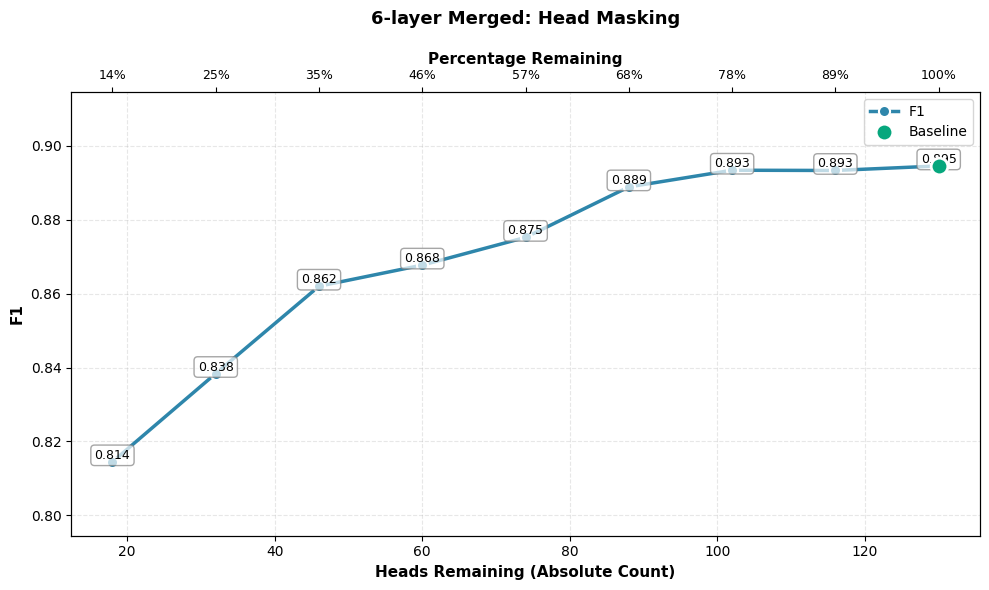

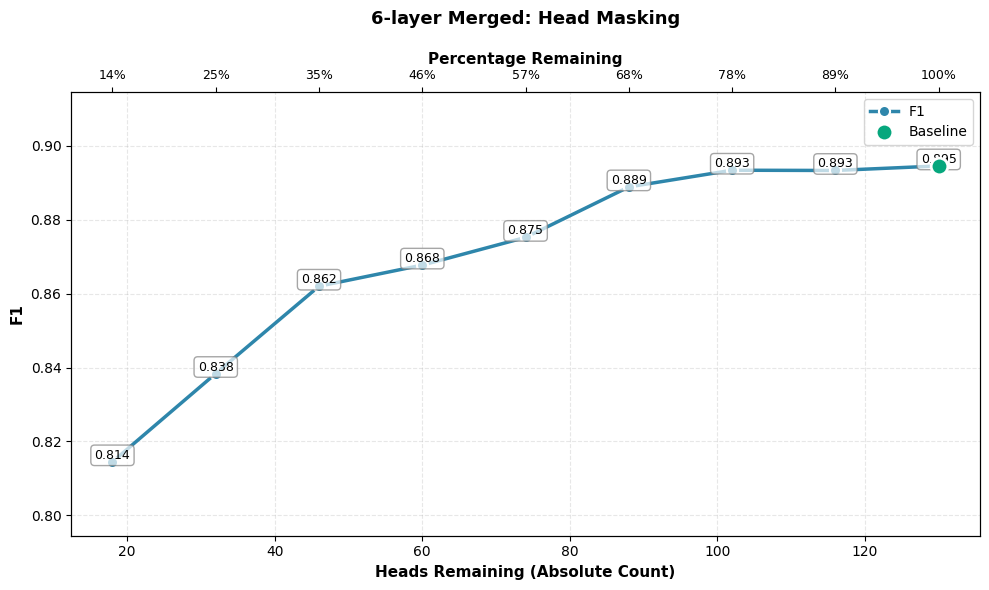

In [75]:
plot_results(
        mask_history_head_6,
        metric='f1',
        component='heads',
        title='6-layer Merged: Head Masking'
)

In [76]:
remove_importance_masks(model_6, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [77]:
torch.save(mask_history_head_6, analysis_save_path + '/head_6.pt')

### Comparision Plot

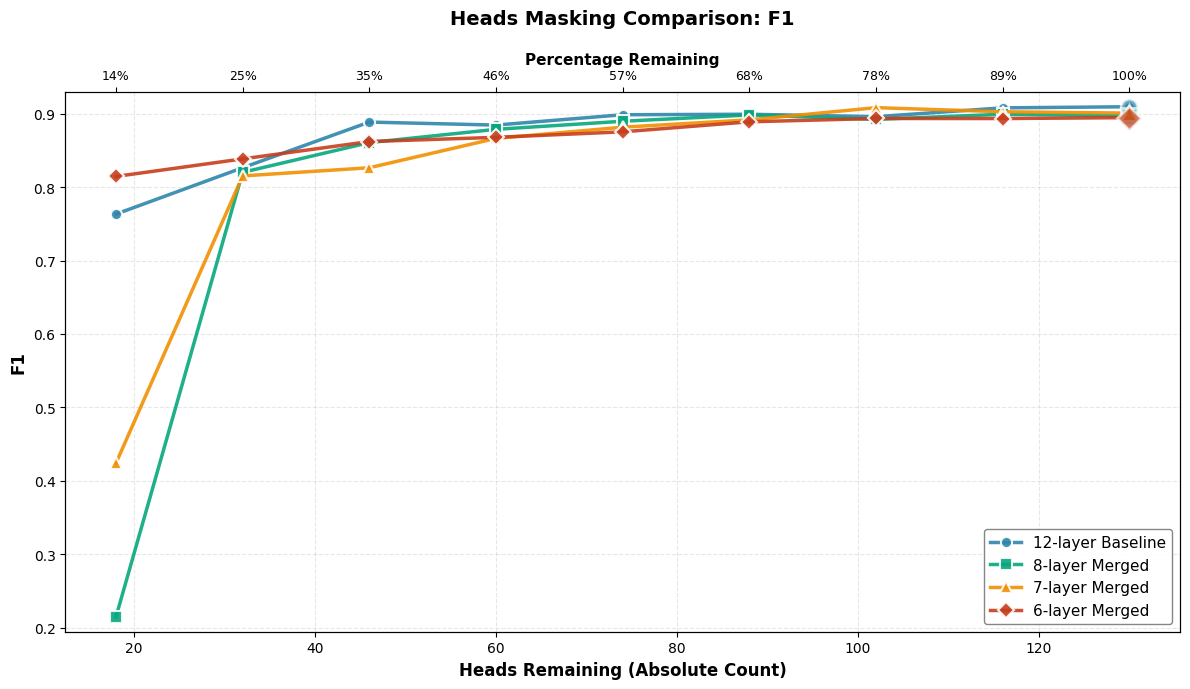

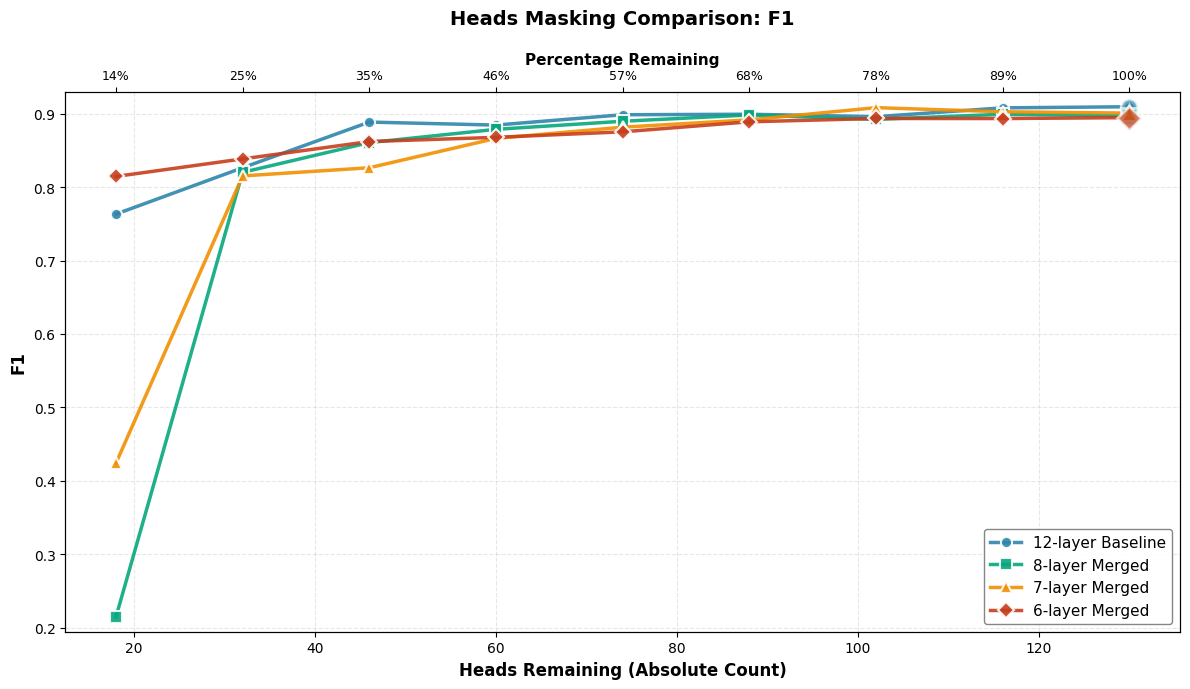

In [78]:
plot_masking_comparison(
    [mask_history_head, mask_history_head_8, mask_history_head_7, mask_history_head_6], 
    labels=['12-layer Baseline', '8-layer Merged', '7-layer Merged', '6-layer Merged'],
    metric='f1', component='heads'
)

## 5.2 FFN Neurons

### 12 Layers

In [79]:
register_importance_masks(model, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (3072 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (3072 neurons)
  Layer 5: Registered masks (3072 neurons)
  Layer 6: Registered masks (3072 neurons)
  Layer 7: Registered masks (3072 neurons)
  Layer 8: Registered masks (3072 neurons)
  Layer 9: Registered masks (3072 neurons)
  Layer 10: Registered masks (3072 neurons)
  Layer 11: Registered masks (3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [80]:
mask_history_neuron = iterativeMask(
    model, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
      accuracy: 0.8676
    ★ f1: 0.9094

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:33<00:00,  2.97it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3069 (99.9%)
Layer: 1, total: 3072, Remain: 3071 (99.97%)
Layer: 2, total: 3072, Remain: 3072 (100.0%)
Layer: 3, total: 3072, Remain: 3071 (99.97%)
Layer: 4, total: 3072, Remain: 3071 (99.97%)
Layer: 5, total: 3072, Remain: 3068 (99.87%)
Layer: 6, total: 3072, Remain: 3067 (99.84%)
Layer: 7, total: 3072, Remain: 3070 (99.93%)
Layer: 8, total: 3072, Remain: 3054 (99.41%)
Layer: 9, total: 3072, Remain: 2656 (86.46%)
Layer: 10, total: 3072, Remain: 1987 (64.68%)
Layer: 11, total: 3072, Remain: 922 (30.01%)
  Metrics:
      accuracy: 0.8676
    ★ f1: 0.9094

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:28<00:00,  3.52it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3062 (99.67%)
Layer: 1, total: 3072, Remain: 3064 (99.74%)
Layer: 2, total: 3072, Remain: 3071 (99.97%)
Layer: 3, total: 3072, Remain: 3067 (99.84%)
Layer: 4, total: 3072, Remain: 3065 (99.77%)
Layer: 5, total: 3072, Remain: 3028 (98.57%)
Layer: 6, total: 3072, Remain: 3035 (98.8%)
Layer: 7, total: 3072, Remain: 3023 (98.4%)
Layer: 8, total: 3072, Remain: 2703 (87.99%)
Layer: 9, total: 3072, Remain: 1371 (44.63%)
Layer: 10, total: 3072, Remain: 711 (23.14%)
Layer: 11, total: 3072, Remain: 292 (9.51%)
  Metrics:
      accuracy: 0.8676
    ★ f1: 0.9094

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1568 (51.04%)
Layer: 1, total: 3072, Remain: 1519 (49.45%)
Layer: 2, total: 3072, Remain: 1567 (51.01%)
Layer: 3, total: 3072, Remain: 1494 (48.63%)
Layer: 4, total: 3072, Remain: 1393 (45.35%)
Layer: 5, total: 3072, Remain: 902 (29.36%)
Layer: 6, total: 3072, Remain: 1018 (33.14%)
Layer: 7, total: 3072, Remain: 856 (27.86%)
Layer: 8, total: 3072, Remain: 492 (16.02%)
Layer: 9, total: 3072, Remain: 150 (4.88%)
Layer: 10, total: 3072, Remain: 67 (2.18%)
Layer: 11, total: 3072, Remain: 36 (1.17%)
  Metrics:
      accuracy: 0.8529
    ★ f1: 0.8936

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:31<00:00,  3.14it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1077 (35.06%)
Layer: 1, total: 3072, Remain: 987 (32.13%)
Layer: 2, total: 3072, Remain: 910 (29.62%)
Layer: 3, total: 3072, Remain: 930 (30.27%)
Layer: 4, total: 3072, Remain: 951 (30.96%)
Layer: 5, total: 3072, Remain: 589 (19.17%)
Layer: 6, total: 3072, Remain: 703 (22.88%)
Layer: 7, total: 3072, Remain: 614 (19.99%)
Layer: 8, total: 3072, Remain: 400 (13.02%)
Layer: 9, total: 3072, Remain: 131 (4.26%)
Layer: 10, total: 3072, Remain: 54 (1.76%)
Layer: 11, total: 3072, Remain: 30 (0.98%)
  Metrics:
      accuracy: 0.7990
    ★ f1: 0.8651

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:30<00:00,  3.32it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 607 (19.76%)
Layer: 1, total: 3072, Remain: 483 (15.72%)
Layer: 2, total: 3072, Remain: 370 (12.04%)
Layer: 3, total: 3072, Remain: 340 (11.07%)
Layer: 4, total: 3072, Remain: 446 (14.52%)
Layer: 5, total: 3072, Remain: 278 (9.05%)
Layer: 6, total: 3072, Remain: 340 (11.07%)
Layer: 7, total: 3072, Remain: 388 (12.63%)
Layer: 8, total: 3072, Remain: 279 (9.08%)
Layer: 9, total: 3072, Remain: 95 (3.09%)
Layer: 10, total: 3072, Remain: 37 (1.2%)
Layer: 11, total: 3072, Remain: 27 (0.88%)
  Metrics:
      accuracy: 0.5907
    ★ f1: 0.5793


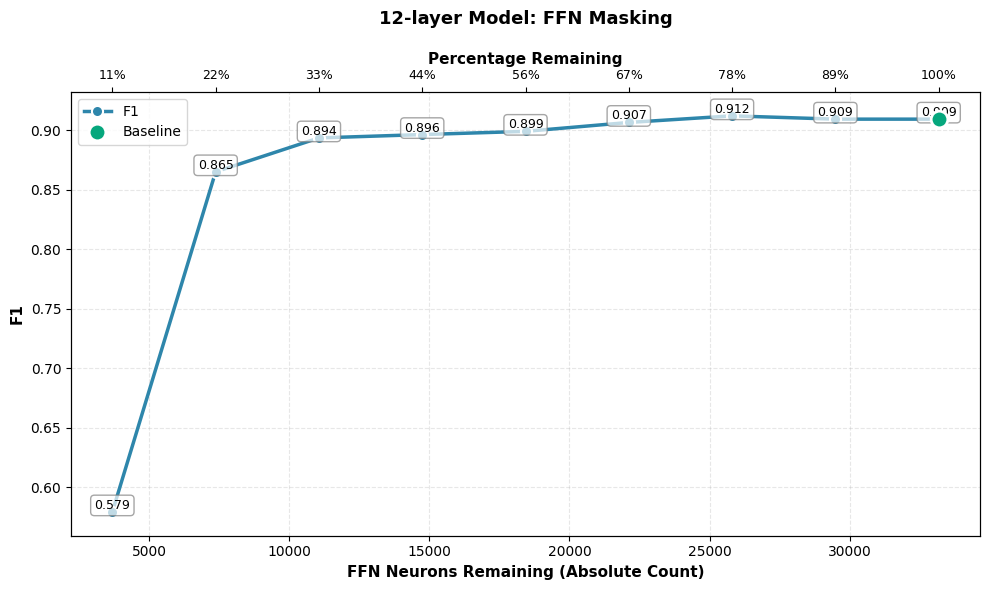

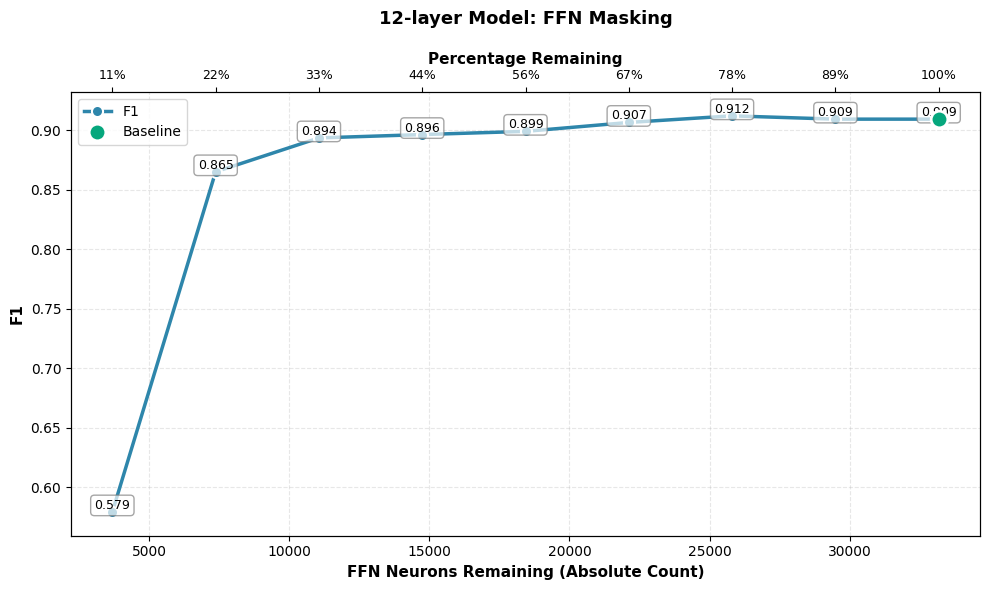

In [81]:
plot_results(mask_history_neuron, metric='f1', component='ffn', title='12-layer Model: FFN Masking')

In [82]:
remove_importance_masks(model, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [83]:
torch.save(mask_history_neuron, analysis_save_path + '/neuron.pt')

### 8 Layers

In [84]:
register_importance_masks(model_8, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (6144 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (3072 neurons)
  Layer 5: Registered masks (6144 neurons)
  Layer 6: Registered masks (3072 neurons)
  Layer 7: Registered masks (9216 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [85]:
mask_history_neuron_8 = iterativeMask(
    model_8, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
      accuracy: 0.8578
    ★ f1: 0.8997

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:27<00:00,  3.58it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3068 (99.87%)
Layer: 1, total: 6144, Remain: 6140 (99.93%)
Layer: 2, total: 3072, Remain: 3070 (99.93%)
Layer: 3, total: 3072, Remain: 3072 (100.0%)
Layer: 4, total: 3072, Remain: 3067 (99.84%)
Layer: 5, total: 6144, Remain: 6129 (99.76%)
Layer: 6, total: 3072, Remain: 3061 (99.64%)
Layer: 7, total: 9216, Remain: 5571 (60.45%)
  Metrics:
      accuracy: 0.8578
    ★ f1: 0.8997

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:27<00:00,  3.59it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3020 (98.31%)
Layer: 1, total: 6144, Remain: 6066 (98.73%)
Layer: 2, total: 3072, Remain: 3058 (99.54%)
Layer: 3, total: 3072, Remain: 3065 (99.77%)
Layer: 4, total: 3072, Remain: 3026 (98.5%)
Layer: 5, total: 6144, Remain: 6004 (97.72%)
Layer: 6, total: 3072, Remain: 2884 (93.88%)
Layer: 7, total: 9216, Remain: 2369 (25.71%)
  Metrics:
      accuracy: 0.8627
    ★ f1: 0.9031

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1477 (48.08%)
Layer: 1, total: 6144, Remain: 2673 (43.51%)
Layer: 2, total: 3072, Remain: 1750 (56.97%)
Layer: 3, total: 3072, Remain: 1692 (55.08%)
Layer: 4, total: 3072, Remain: 1170 (38.09%)
Layer: 5, total: 6144, Remain: 1797 (29.25%)
Layer: 6, total: 3072, Remain: 391 (12.73%)
Layer: 7, total: 9216, Remain: 112 (1.22%)
  Metrics:
      accuracy: 0.8554
    ★ f1: 0.8967

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:29<00:00,  3.40it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1096 (35.68%)
Layer: 1, total: 6144, Remain: 1822 (29.65%)
Layer: 2, total: 3072, Remain: 1083 (35.25%)
Layer: 3, total: 3072, Remain: 1105 (35.97%)
Layer: 4, total: 3072, Remain: 680 (22.14%)
Layer: 5, total: 6144, Remain: 1207 (19.65%)
Layer: 6, total: 3072, Remain: 291 (9.47%)
Layer: 7, total: 9216, Remain: 92 (1.0%)
  Metrics:
      accuracy: 0.8235
    ★ f1: 0.8719

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:30<00:00,  3.30it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 600 (19.53%)
Layer: 1, total: 6144, Remain: 784 (12.76%)
Layer: 2, total: 3072, Remain: 409 (13.31%)
Layer: 3, total: 3072, Remain: 522 (16.99%)
Layer: 4, total: 3072, Remain: 300 (9.77%)
Layer: 5, total: 6144, Remain: 793 (12.91%)
Layer: 6, total: 3072, Remain: 213 (6.93%)
Layer: 7, total: 9216, Remain: 69 (0.75%)
  Metrics:
      accuracy: 0.6936
    ★ f1: 0.7401


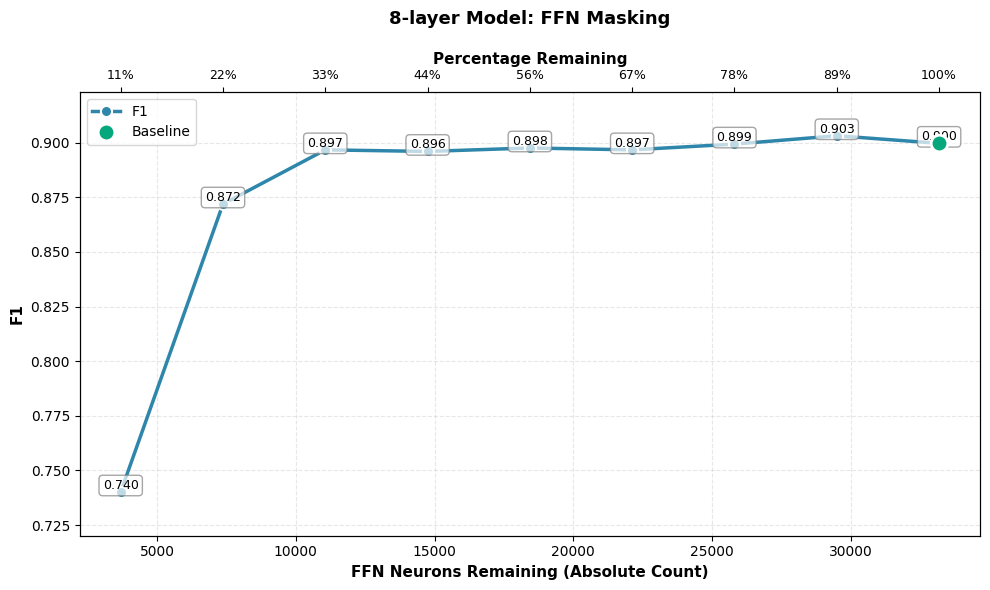

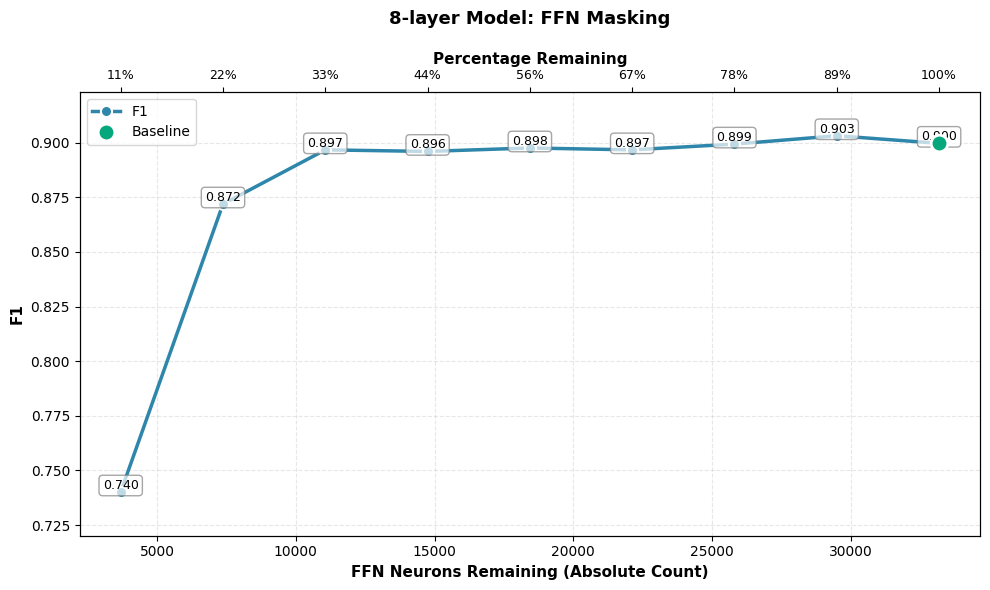

In [86]:
plot_results(mask_history_neuron_8, metric='f1', component='ffn', title='8-layer Model: FFN Masking')

In [87]:
remove_importance_masks(model_8, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [88]:
torch.save(mask_history_neuron_8, analysis_save_path + '/neuron_8.pt')

### 7 Layers

In [89]:
register_importance_masks(model_7, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (6144 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (3072 neurons)
  Layer 5: Registered masks (6144 neurons)
  Layer 6: Registered masks (12288 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [90]:
mask_history_neuron_7 = iterativeMask(
    model_7, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
      accuracy: 0.8701
    ★ f1: 0.9085

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:29<00:00,  3.42it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3070 (99.93%)
Layer: 1, total: 6144, Remain: 6141 (99.95%)
Layer: 2, total: 3072, Remain: 3072 (100.0%)
Layer: 3, total: 3072, Remain: 3072 (100.0%)
Layer: 4, total: 3072, Remain: 3067 (99.84%)
Layer: 5, total: 6144, Remain: 6136 (99.87%)
Layer: 6, total: 12288, Remain: 8620 (70.15%)
  Metrics:
      accuracy: 0.8701
    ★ f1: 0.9085

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:30<00:00,  3.27it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3070 (99.93%)
Layer: 1, total: 6144, Remain: 6139 (99.92%)
Layer: 2, total: 3072, Remain: 3071 (99.97%)
Layer: 3, total: 3072, Remain: 3071 (99.97%)
Layer: 4, total: 3072, Remain: 3060 (99.61%)
Layer: 5, total: 6144, Remain: 6107 (99.4%)
Layer: 6, total: 12288, Remain: 4974 (40.48%)
  Metrics:
      accuracy: 0.8652
    ★ f1: 0.9053

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1395 (45.41%)
Layer: 1, total: 6144, Remain: 2720 (44.27%)
Layer: 2, total: 3072, Remain: 1954 (63.61%)
Layer: 3, total: 3072, Remain: 1837 (59.8%)
Layer: 4, total: 3072, Remain: 1223 (39.81%)
Layer: 5, total: 6144, Remain: 1694 (27.57%)
Layer: 6, total: 12288, Remain: 239 (1.94%)
  Metrics:
      accuracy: 0.8382
    ★ f1: 0.8850

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:31<00:00,  3.17it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1045 (34.02%)
Layer: 1, total: 6144, Remain: 1819 (29.61%)
Layer: 2, total: 3072, Remain: 1181 (38.44%)
Layer: 3, total: 3072, Remain: 1188 (38.67%)
Layer: 4, total: 3072, Remain: 716 (23.31%)
Layer: 5, total: 6144, Remain: 1232 (20.05%)
Layer: 6, total: 12288, Remain: 195 (1.59%)
  Metrics:
      accuracy: 0.8333
    ★ f1: 0.8799

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:27<00:00,  3.65it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 676 (22.01%)
Layer: 1, total: 6144, Remain: 878 (14.29%)
Layer: 2, total: 3072, Remain: 459 (14.94%)
Layer: 3, total: 3072, Remain: 565 (18.39%)
Layer: 4, total: 3072, Remain: 299 (9.73%)
Layer: 5, total: 6144, Remain: 674 (10.97%)
Layer: 6, total: 12288, Remain: 139 (1.13%)
  Metrics:
      accuracy: 0.7819
    ★ f1: 0.8311


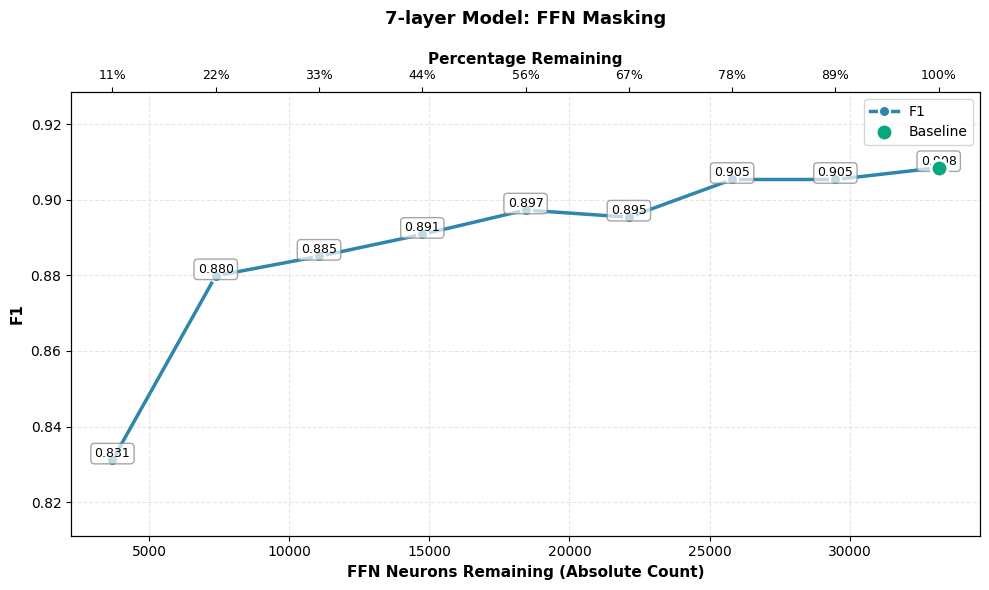

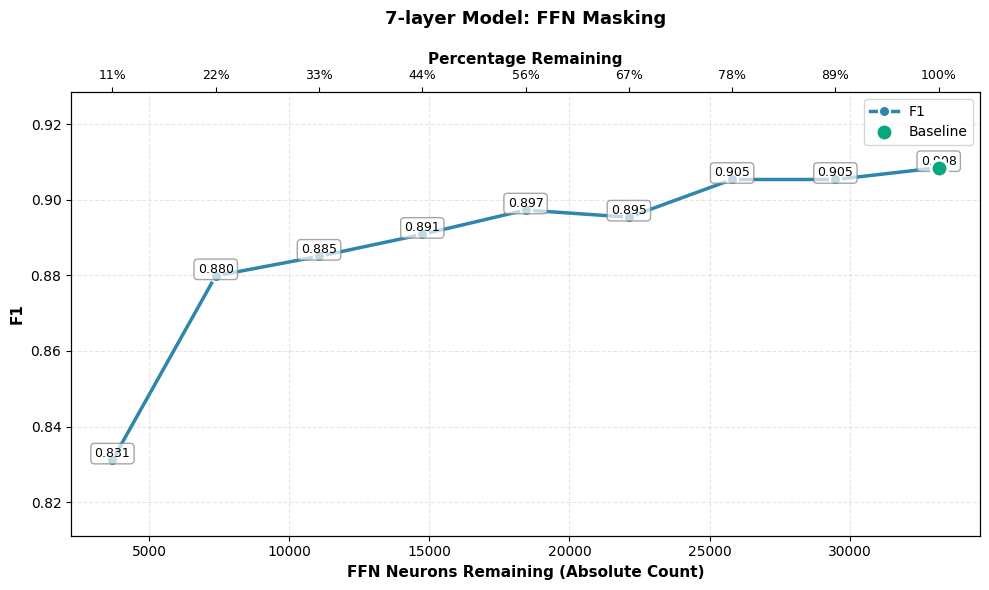

In [91]:
plot_results(mask_history_neuron_7, metric='f1', component='ffn', title='7-layer Model: FFN Masking')

In [92]:
remove_importance_masks(model_7, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [93]:
torch.save(mask_history_neuron_7, analysis_save_path + '/neuron_7.pt')

### 6 Layers

In [94]:
register_importance_masks(model_6, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (6144 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (9216 neurons)
  Layer 5: Registered masks (12288 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [95]:
mask_history_neuron_6 = iterativeMask(
    model_6, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
      accuracy: 0.8480
    ★ f1: 0.8938

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:28<00:00,  3.46it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3069 (99.9%)
Layer: 1, total: 6144, Remain: 6143 (99.98%)
Layer: 2, total: 3072, Remain: 3072 (100.0%)
Layer: 3, total: 3072, Remain: 3072 (100.0%)
Layer: 4, total: 9216, Remain: 9187 (99.69%)
Layer: 5, total: 12288, Remain: 8635 (70.27%)
  Metrics:
      accuracy: 0.8505
    ★ f1: 0.8957

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:29<00:00,  3.39it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3063 (99.71%)
Layer: 1, total: 6144, Remain: 6139 (99.92%)
Layer: 2, total: 3072, Remain: 3071 (99.97%)
Layer: 3, total: 3072, Remain: 3070 (99.93%)
Layer: 4, total: 9216, Remain: 9070 (98.42%)
Layer: 5, total: 12288, Remain: 5079 (41.33%)
  Metrics:
      accuracy: 0.8529
    ★ f1: 0.8976

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1525 (49.64%)
Layer: 1, total: 6144, Remain: 2903 (47.25%)
Layer: 2, total: 3072, Remain: 2001 (65.14%)
Layer: 3, total: 3072, Remain: 2021 (65.79%)
Layer: 4, total: 9216, Remain: 2377 (25.79%)
Layer: 5, total: 12288, Remain: 235 (1.91%)
  Metrics:
      accuracy: 0.8431
    ★ f1: 0.8885

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:25<00:00,  3.95it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1008 (32.81%)
Layer: 1, total: 6144, Remain: 1902 (30.96%)
Layer: 2, total: 3072, Remain: 1264 (41.15%)
Layer: 3, total: 3072, Remain: 1327 (43.2%)
Layer: 4, total: 9216, Remain: 1682 (18.25%)
Layer: 5, total: 12288, Remain: 193 (1.57%)
  Metrics:
      accuracy: 0.8186
    ★ f1: 0.8733

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:23<00:00,  4.20it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 716 (23.31%)
Layer: 1, total: 6144, Remain: 1025 (16.68%)
Layer: 2, total: 3072, Remain: 484 (15.76%)
Layer: 3, total: 3072, Remain: 578 (18.82%)
Layer: 4, total: 9216, Remain: 745 (8.08%)
Layer: 5, total: 12288, Remain: 142 (1.16%)
  Metrics:
      accuracy: 0.7696
    ★ f1: 0.8142


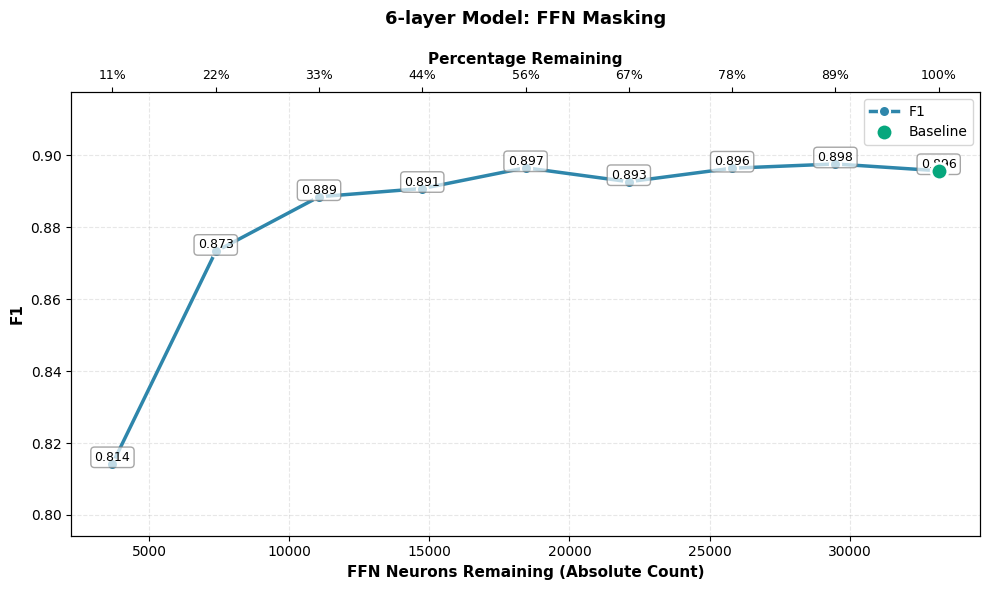

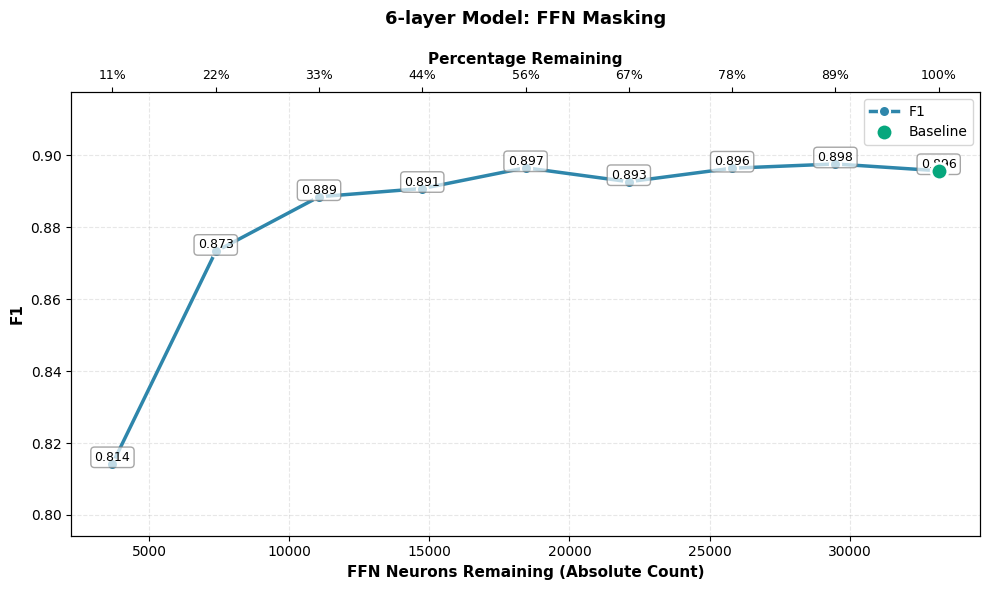

In [96]:
plot_results(mask_history_neuron_6, metric='f1', component='ffn', title='6-layer Model: FFN Masking')

In [97]:
remove_importance_masks(model_6, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [98]:
torch.save(mask_history_neuron_6, analysis_save_path + '/neuron_6.pt')

### Plot Comparision

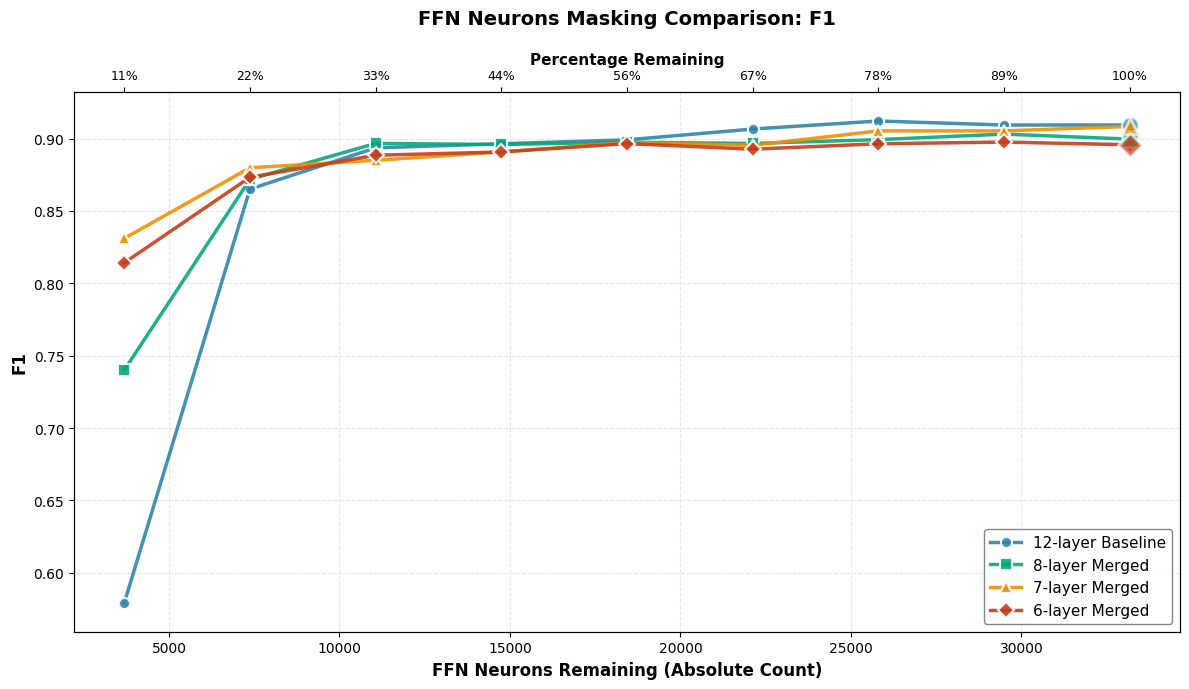

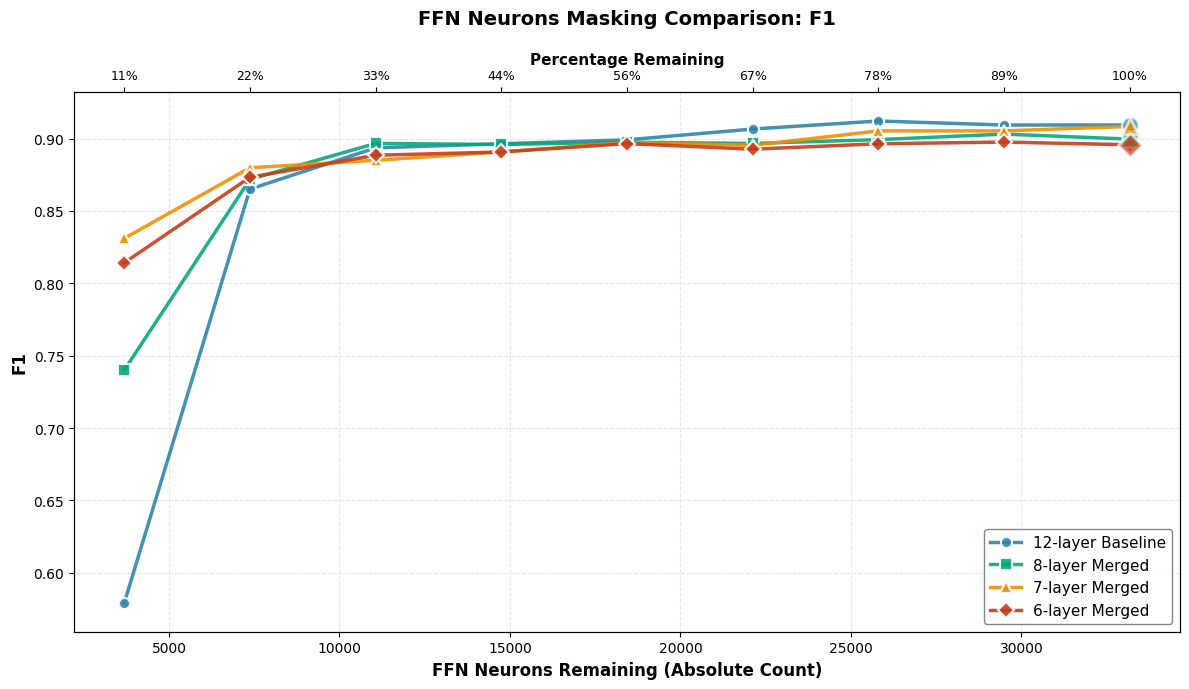

In [99]:
plot_masking_comparison(
    [mask_history_neuron, mask_history_neuron_8, mask_history_neuron_7, mask_history_neuron_6], 
    labels=['12-layer Baseline', '8-layer Merged', '7-layer Merged', '6-layer Merged'], 
    metric='f1', component='ffn'
)